In [ ]:
import yfinance as yf
import numpy as np
from datetime import datetime
import requests
import pandas as pd

def get_market_data(ticker_symbol: str, expiry_date: str, strike: float):
    """
    Récupère toutes les données nécessaires au modèle binomial.
    
    ticker_symbol : ex. "AAPL"
    expiry_date   : ex. "2025-06-20" (doit être une date disponible sur le marché)
    strike        : prix d'exercice souhaité
    """

    ticker = yf.Ticker(ticker_symbol)

    # --- 1. Cours actuel de l'action ---
    S0 = ticker.history(period="1d")["Close"].iloc[-1]

    # --- 2. Taux sans risque en composition continue ---
    # Taux du T-Bill 3 mois depuis FRED
    fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DTB3"

    tbill_data = pd.read_csv(fred_url, index_col=0, parse_dates=True)
    tbill_data = tbill_data[tbill_data["DTB3"] != "."]
    r_nominal = float(tbill_data["DTB3"].iloc[-1]) / 100  # en décimal
    r = np.log(1 + r_nominal)                             # composition continue

    # --- 3. Volatilité historique (annualisée) ---
    hist = ticker.history(period="1y")["Close"]
    log_returns = np.log(hist / hist.shift(1)).dropna()
    sigma = log_returns.std() * np.sqrt(252)              # annualisée (252 jours de bourse)

    # --- 4. Prix d'exercice et maturité (depuis la chaîne d'options) ---
    option_chain = ticker.option_chain(expiry_date)
    calls = option_chain.calls
    puts  = option_chain.puts

    # Sélection du call le plus proche du strike demandé
    call_row = calls.iloc[(calls["strike"] - strike).abs().argmin()]
    put_row  = puts.iloc[(puts["strike"]   - strike).abs().argmin()]

    K      = call_row["strike"]
    T_days = (datetime.strptime(expiry_date, "%Y-%m-%d") - datetime.today()).days
    T      = T_days / 365                                 # maturité en années

        # yfinance fournit l'IV directement dans la chaîne d'options
    option_chain = ticker.option_chain(expiry_date)
    calls = option_chain.calls

    # Sélection du strike le plus proche
    call_row = calls.iloc[(calls["strike"] - strike).abs().argmin()]

    sigma_implicite = call_row["impliedVolatility"]  # annualisée, à utiliser directement
    

    return {
        "S0"            : round(S0, 4),
        "K"             : K,
        "r"             : round(r, 6),
        "sigma IV"         : round(sigma_implicite, 6),
        "T"             : round(T, 6),
        "T_days"        : T_days,
        "call_market"   : call_row["lastPrice"],
        "put_market"    : put_row["lastPrice"],
    }

# Exemple d'utilisation
data = get_market_data("NVDA", "2026-11-20", strike=185)
print(data)



{'S0': np.float64(201.68), 'dividendes': Date
2012-11-20 00:00:00-05:00    0.001875
2013-02-26 00:00:00-05:00    0.001875
2013-05-21 00:00:00-04:00    0.001875
2013-08-20 00:00:00-04:00    0.001875
2013-11-19 00:00:00-05:00    0.002125
2014-02-25 00:00:00-05:00    0.002125
2014-05-20 00:00:00-04:00    0.002125
2014-08-19 00:00:00-04:00    0.002125
2014-11-19 00:00:00-05:00    0.002125
2015-02-24 00:00:00-05:00    0.002125
2015-05-19 00:00:00-04:00    0.002450
2015-08-18 00:00:00-04:00    0.002450
2015-11-18 00:00:00-05:00    0.002875
2016-02-29 00:00:00-05:00    0.002875
2016-05-24 00:00:00-04:00    0.002875
2016-08-23 00:00:00-04:00    0.002875
2016-11-23 00:00:00-05:00    0.003500
2017-02-22 00:00:00-05:00    0.003500
2017-05-19 00:00:00-04:00    0.003500
2017-08-22 00:00:00-04:00    0.003500
2017-11-22 00:00:00-05:00    0.003750
2018-02-22 00:00:00-05:00    0.003750
2018-05-23 00:00:00-04:00    0.003750
2018-08-29 00:00:00-04:00    0.003750
2018-11-29 00:00:00-05:00    0.004000
2019

In [22]:
import numpy as np
from math import *

def binomial_european(S0, K, r, sigma, T, n, option_type="call"):
    """
    T : maturité résiduelle en années (peut être un décimal quelconque)
    n : nombre de pas (entier, choisi librement)
    """
    dt    = T / n                        # durée d'un pas (fraction d'année)
    u     = np.exp(sigma * np.sqrt(dt))  # facteur de hausse
    d     = 1 / u                        # facteur de baisse
    p     = (np.exp(r * dt) - d) / (u - d)  # probabilité risque-neutre

    # Valeurs terminales
    ST = np.array([S0 * u**j * d**(n-j) for j in range(n+1)])
    
    if option_type == "call":
        payoffs = np.maximum(ST - K, 0)
    else:
        payoffs = np.maximum(K - ST, 0)

    # Actualisation récursive
    for i in range(n - 1, -1, -1):
        payoffs = np.exp(-r * dt) * (p * payoffs[1:i+2] + (1-p) * payoffs[:i+1])

    return payoffs[0]

binomial_european(201.68,185,0.03556,0.472478,0.586301,10000)

np.float64(38.909945060323146)

I - Calcul de l'option d'une maturité (tronnquée à) : 10 étapes de 0.7035612 mois, soit une maturité de 0 ans et 7.0356119999999995 mois, avec des périodes de 0.7035612 mois.






III - p : 0.4805 | 1-p : 0.5195 | Coeff d'actualisation : 0.9979

III - Liste des payoffs finaux : [448.16063999999994, 318.66723, 215.65769, 133.71555999999998, 68.53216, 16.680000000000007, 0, 0, 0, 0, 0]
III - Prix de l'option à l'étape 9 : [380.09962, 264.60479, 172.73085, 99.64688, 41.50997, 7.99857, 0.0, 0.0, 0.0, 0.0]
III - Prix de l'option à l'étape 8 : [319.43703, 216.42749, 134.48536, 69.30196, 24.05166, 3.83556, 0.0, 0.0, 0.0]
III - Prix de l'option à l'étape 7 : [265.37299, 173.49905, 100.41508, 45.70048, 13.52182, 1.83927, 0.0, 0.0]
III - Prix de l'option à l'étape 6 : [217.19409, 135.25196, 71.84264, 28.92432, 7.43758, 0.88199, 0.0]
III - Prix de l'option à l'étape 5 : [174.26405, 102.09974, 49.44474, 17.72564, 4.02376, 0.42294]
III - Prix de l'option à l'étape 4 : [136.49211, 74.59146, 32.8990

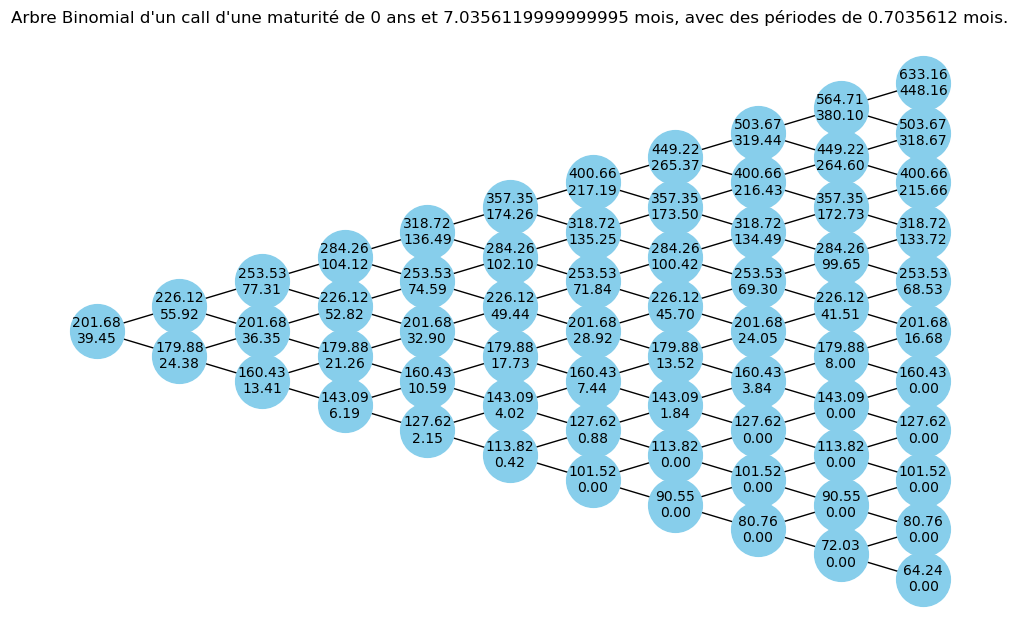

In [20]:
#Objectif du code : calculer le prix d'une option européenne à travers un arbre binomial
#Nous supposons :
# - S_0 = 50;
# - u = exp(0.3);
# - d = exp(-0.3);
# - r_c = 0.02 (taux continu).

#Ce code permet à l'utilisateur de calculer des calls/puts européens, selon la maturité et la durée d'une période/pas qu'il souhaite.
#L'utilisateur peut remplacer nos valeurs arbitraires de S_0, u, d et r_c s'il le souhaite.
 
from math import *
import matplotlib.pyplot as plt
import networkx as nx
#Code visant à calculer les prix des actions à chaque branche, soit les prix des actions à chaque période t.

#Détermination du cours actuel du sous-jacent, des coefficients à la hausse et à la baisse.
S_0 = 201.68
periode = 0.586301/10
sigma = 0.472478
u = exp(sigma*sqrt(periode))
d = exp(-sigma*sqrt(periode))

def calcul_prix_option_europeenne(call:bool,put:bool,n:float,delta_t:float):

    #I - Gestion des erreurs et des incompatibilités entre la maturité considérée et les périodes de calcul.
    if delta_t>n:
        return "Vous ne pouvez pas avoir une période de calcul plus grande que la maturité de l'option."

    if n<0:
        return "Vous ne pouvez pas calculer une option avec une maturité négative."

    if delta_t<0:
        return "Vous ne pouvez pas calculer une option avec une période négative."

    #nouvelle maturité considérée (si l'ancienne maturité n'est pas un multiplicateur de la période delta_t)
    #delta_t*12 = nombre de mois (car delta_t est exprimé en années)
    #n*delta_t = nombre de périodes totales en années = maturité en années
    # => int(n*delta_t) = partie "années" de la maturité
    # => (n*delta_t-int(n*delta_t)) = partie "mois" de la maturité, exprimée en années
    # => (n*delta_t-int(n*delta_t))*12 = partie "mois" de la maturité exprimée en mois
    n = int(n/delta_t)  #tronque à l'entier inférieur

    if n==1:
        print(f"I - Calcul de l'option d'une maturité (tronnquée à) : {n} étape de {delta_t*12} mois, soit une maturité de {int(n*delta_t)} ans et {(n*delta_t-int(n*delta_t))*12} mois, avec des périodes de {delta_t*12} mois.")
    else:
        print(f"I - Calcul de l'option d'une maturité (tronnquée à) : {n} étapes de {delta_t*12} mois, soit une maturité de {int(n*delta_t)} ans et {(n*delta_t-int(n*delta_t))*12} mois, avec des périodes de {delta_t*12} mois.")

    if call==True and put==True or call==False and put==False:
        return "Veuillez choisir l'option dont vous souhaitiez calculer le prix."









    print("\n"*2)
    ###########################################################################################################################################
    #II - Calcul de l'ensemble des cours de l'action à chaque noeud

    #Initialisation de la liste des étapes (étape = ensemble des noeuds à une période donnée).
    #On choisit d'utiliser 6 étapes : E0, E1, E2, E3, ..., En. L'arbre a donc n périodes (= t0, t1, t2, t3, ..., tn)
    liste_noms = [[S_0]]+[[] for _ in range(n)]
    #Note : on a mis S_0 dans une liste, car la boucle du dessous va itérer sur des objets itérables, et que S_0 en tant que tel n'est pas un objet itérable

    for k in range(1,n+1,1):    #Pour chaque étape (E1, E2, E3, ..., En)

        #Affichage du contenu des étapes pré-remplissage
        #On affiche à quelle date t on est, et les éléments de l'étape précédente que l'on va utiliser pour trouver les cours pour cette étape.
        #print(f"II - Affichage pré-remplissage E{k} : E{k} = {liste_noms[k]} | E{k-1} = {liste_noms[k-1]}")
        etape_actuelle = liste_noms[k]
        etape_precedente = liste_noms[k-1]

        #Pour une étape k donnée, on ajoute les évolutions de cours dans l'étape k+1
        for element in etape_precedente: #Pour chaque élément de l'étape précédente (E0 pour E1, E1 pour E2, E2 pour E3, etc.)

            #Calcul des évolutions de cours
            prix_hausse = round(element*u,5) #calcul du cours évolué, dans le cas d'une hausse
            prix_baisse = round(element*d,5) #calcul du cours évolué, dans le cas d'une baisse

            #Ajout des évolutions de cours
            if prix_hausse not in etape_actuelle:  #Si le cours évolué à la hausse n'est pas dans l'étape k, on la rajoute
                etape_actuelle.append(prix_hausse)
            if prix_baisse not in etape_actuelle:  #Si le cours évolué à la baisse n'est pas dans l'étape k, on la rajoute
                etape_actuelle.append(prix_baisse)

    #Après avoir calculé l'ensemble des cours possibles (=ensemble des noeuds possibles), on les affiche
    #Affichage des différentes étapes et leur contenu.
    #print("\nII - Affichage des noeuds à chaque étape")
    #for j in range(len(liste_noms)):
     #   print(f"II- E{j} = {liste_noms[j]}")




    print("\n"*2)
    ###########################################################################################################################################
    #III - Calcul du prix de l'option, call ou put

    prix_exercice = 185
    r_c = 0.03556
    p = (exp(r_c*delta_t)-d)/(u-d)
    coeff_actualisation = exp(-r_c*delta_t)
    print(f"III - p : {p:.4f} | 1-p : {1-p:.4f} | Coeff d'actualisation : {coeff_actualisation:.4f}\n")

    #Création des listes qui vont contenir les prix de l'option à chaque étape.
    #Donc :
        #L_5 contient les payoffs finaux (= prix de l'option à la date finale, selon les chemins d'évolutions),
        #L_4 contient les prix de l'option à l'étape E4 <=> contient [f_4u; f_3u1d; f_2u2d; f_1u3d; f_4d],
        #L_3 contient les prix de l'option à l'étape E3 <=> contient [f_3u; f_2u1d; f_1u2d; f_3d],
        #L_2 contient les prix de l'option à l'étape E2 <=> contient [f_2u; f_1u1d; f_2d],
        #L_1 contient les prix de l'option à l'étape E1 <=> contient [f_u; f_d],
        #L_0 contient le prix de l'option aujourd'hui.
    #On crée à part la liste contenant les payoffs finaux, pour "visuellement initialiser", et donc bien distinguer les payoffs finaux des payoffs intermédiaires.
    #liste_payoffs_finaux contient l'ensemble des payoffs finaux d'un call, où le premier indice est le noeud final le plus haut,
    #et le dernier indice est le noeud final le plus bas.
    liste_prix_options = [0]+[[] for _ in range(n)]
    #note : on a écrit "[0] + [...]" car si l'on avait écrit "[] + [...]", la liste vide créée aurait été écrasée par la liste de compréhension, et il y aurait eu une erreur

    def payoffs_call(): #Fonction qui calcule les payoffs terminaux d'un call
        return [max(0,prix-prix_exercice) for prix in liste_noms[n]]
    def payoffs_put():  #Fonction qui calcule les payoffs terminaux d'un put
        return [max(0,prix_exercice-prix) for prix in liste_noms[n]]

    liste_payoffs_finaux = []
    if call:
        liste_payoffs_finaux = payoffs_call()
    elif put:
        liste_payoffs_finaux = payoffs_put()

    liste_prix_options[n] = liste_payoffs_finaux
    print(f"III - Liste des payoffs finaux : {liste_payoffs_finaux}")
    #Note : on a crée au préalable "liste_payoffs_finaux = []" afin d'éviter que Python ne souligne la ligne de code en jaune


    #Calcul du prix de l'option, à chaque noeud de la date t.
    #Première boucle : pour chaque étape E_k, ...
    for numero_etape in range(n-1,0,-1):
        #Idée : pour chaque noeud de l'étape k-1, on a :
        # - le noeud n°1 de E_k-1 (= noeud le plus haut de E_k-1) qui va utiliser les noeuds n°1 et n°2 de E_k
        # - le noeud n°2 de E_k-1 (= 2e noeud le plus haut de E_k-1) qui va utiliser les noeuds n°2 et n°3 de E_k
        # - le noeud n°3 de E_k-1 (= 3e noeud le plus haut de E_k-1) qui va utiliser les noeuds n°3 et n°4 de E_k
        # - etc.
        #Rappel : E_k = liste_noms[k]. L'étape n°k est l'élément n°k de liste_noms.

        etape = liste_noms[numero_etape]

        #... prendre les noeuds de l'étape E_k+1, et calculer le prix de l'option à chaque noeud de l'étape E_k
        etape_suivant = liste_prix_options[numero_etape+1]
        for noeud in etape: #pour chaque noeud de l'étape E_k :
            #on calcule l'indice du noeud, et on calcule le prix de l'option au noeud n°j en mobilisant les noeuds n°j et j-1 de l'étape suivante
            #puis, on ajoute ce prix de l'option, pour le noeud actuel de l'étape E_k, à la liste L_k.
            indice_noeud = etape.index(noeud)
            prix_option = coeff_actualisation*( (p*etape_suivant[indice_noeud]) + ((1-p)*etape_suivant[indice_noeud + 1]) )
            liste_prix_options[numero_etape].append(round(prix_option,5))

        print(f"III - Prix de l'option à l'étape {numero_etape} : {liste_prix_options[numero_etape]}")

    #Calcul du prix de l'option à la date d'aujourd'hui
    prix_option_ajd = coeff_actualisation*( (p*liste_prix_options[1][0]) + ((1-p)*liste_prix_options[1][1]) )
    liste_prix_options[0] = [prix_option_ajd]

   #Arrondi des cours de l'action
    for j in range(len(liste_noms)):
        for i in range(len(liste_noms[j])):
            liste_noms[j][i] = round(liste_noms[j][i],2)

    print(f"\nIII - Liste des cours de l'action, à chaque étape : {liste_noms}")
    print(f"III - Valeurs des prix des options : {liste_prix_options}") #Affichage des prix de l'option à chaque date/étape.
    print(f"III - Prix de l'option aujourd'hui : {prix_option_ajd:.4f}")    #Affichage du prix de l'option à la date d'aujourd'hui.




    print("\n"*2)
    ###########################################################################################################################################
    #IV - Traçage de l'arbre binomial

    graphe = nx.Graph() #Création du graphe (vide pour l'instant)
    pos = {}    #pos représente les noeuds du graphe
    labels = {} #labels des noeuds

    #Génération des nœuds et des positions
    for etape in range(n+1):    #Pour chaque étape, ...
        for index in range(etape + 1):  #Pour chaque noeud/index, on crée un identifiant unique (étape,noeud/index) que l'on ajoute au graphique
            #Identification unique du nœud (étape, index), et ajout de ce noeud au graphe.
            node_id = (etape,index)
            graphe.add_node(node_id)

            #Ajout du cours de l'action au noeud actuel
            cours_action = liste_noms[etape][index]
            prix_option = liste_prix_options[etape][index]
            labels[node_id] = f"{cours_action:.2f}\n{prix_option:.2f}"

            #Positionnement (x = étape, y = décalage vertical)
            #Pour l'étape 0 : (0,0)
            #Pour l'étape 1 : (1,1) et (1,-1)
            #Pour l'étape 2 : (2,2) et (2,0) et (2,-2)
            #Pour l'étape 3 : (3,3) et (3,1) et (3,-1) et (3,-3)
            #etc.
            pos[node_id] = (etape,etape-2*index)

            #Si l'index est positif, on ne dessine que les traits/liens vers le haut reliant les noeuds n°i de E_k et n°i-1 de E_k-1
            if index > 0: #Lien vers le haut (lien du noeud n°i de l'étape E_k vers le noeud n°i-1 de l'étape E_k-1)
                graphe.add_edge((etape - 1, index - 1), node_id)
            #Si le numéro d'index est inférieur au numéro de l'étape actuel, on dessine un trait/lien vers le haut reliant les noeuds n°i de E_k et n°i de E_k-1
            if index < etape: #Lien vers le bas (lien du noeud n°i de l'étape E_k vers le noeud n°i de l'étape E_k-1)
                graphe.add_edge((etape - 1, index), node_id)

    plt.figure(figsize=(10, 6))
    nx.draw(graphe, pos, with_labels=False, node_size=1500, node_color="skyblue")
    nx.draw_networkx_labels(graphe, pos, labels, font_size=10)

    if call:
        plt.title(f"Arbre Binomial d'un call d'une maturité de {int(n*delta_t)} ans et {(n*delta_t-int(n*delta_t))*12} mois, avec des périodes de {delta_t*12} mois.")
    elif put:
        plt.title(f"Arbre binomial d'un put d'une maturité de {int(n*delta_t)} ans et {(n*delta_t-int(n*delta_t))*12} mois, avec des périodes de {delta_t*12} mois.")

    plt.show()



calcul_prix_option_europeenne(call=True,put=False,n=0.586301,delta_t=periode)